# Moteur de risque multi-actifs : VaR, Expected Shortfall et validation
### Mesure, décomposition, backtesting et passage à un risque conditionnel sur un portefeuille multi-actifs

**Réalisé par Kim TRINH**

Dans ce projet, je construis un moteur de mesure du risque de marché d'un portefeuille multi-actifs (actions, taux, crédit, or, pétrole, dollar). J'estime la **Value-at-Risk (VaR)** et l'**Expected Shortfall (ES)** par trois méthodes indépendantes (paramétrique, historique, Monte-Carlo), je **décompose** le risque actif par actif, puis je **valide statistiquement** le modèle par backtesting (tests de Kupiec et de Christoffersen). Je montre que le modèle a le bon *nombre* de dépassements mais que ceux-ci sont *regroupés dans le temps*, ce qui est la signature du clustering de volatilité, et cela me conduit à une mesure **conditionnelle** (EWMA puis GARCH-FHS). Je termine par des scénarios de **stress**, un **scorecard** comparatif des modèles.

J'aborde ce projet comme le pendant *risque* d'un pricer : là où un pricer démontre qu'on sait valoriser, ce moteur démontre qu'on sait **gérer le risque d'un book**. La couche de validation statistique correspond d'ailleurs exactement au travail des équipes Model Validation et Quant Risk.

# Plan du notebook

**A. Données et diagnostics**
1. Partie I : imports et paramètres globaux
2. Partie II : collecte et préparation des données
3. Partie III : première exploration, portefeuille et corrélations
4. Partie IV : diagnostics distributionnels, la question des queues épaisses

**B. Mesure du risque (VaR / ES)**
5. Partie V : méthode paramétrique (normale, Student-t, Cornish-Fisher)
6. Partie VI : méthode historique
7. Partie VII : méthode Monte-Carlo (Cholesky)
8. Partie VIII : comparaison des trois méthodes

**C. Décomposition et validation**
9. Partie IX : décomposition du risque (VaR par composante)
10. Partie X : backtesting (Kupiec et Christoffersen)

**D. Risque conditionnel, stress et bilan**
11. Partie XI : risque conditionnel, EWMA puis GARCH-FHS
12. Partie XII : stress testing
13. Partie XIII : scorecard, quel modèle de VaR retenir
14. Partie XIV : bilan et limites

# Partie I : imports et paramètres globaux

Je commence par rassembler les imports, fixer une graine aléatoire pour la reproductibilité, et centraliser les réglages du projet au même endroit (niveau de confiance, valeur du portefeuille). Je procède ainsi pour ne pas avoir à parcourir tout le notebook lorsque je veux modifier un réglage.

In [1]:
# Imports : calcul numerique, donnees, graphiques, statistiques, donnees de marche, GARCH
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf
from arch import arch_model

Je fixe une graine globale. Les seules parties aléatoires du projet sont le Monte-Carlo et le bootstrap de la FHS, et je leur passe en plus leur propre graine, de sorte que deux exécutions successives donnent exactement les mêmes chiffres. La reproductibilité est essentielle ici : sans elle, je ne pourrais pas savoir si un écart entre deux résultats vient d'un choix de modélisation ou simplement du tirage aléatoire.

In [2]:
# Je fixe la graine pour rendre tout le notebook reproductible
GRAINE = 42
np.random.seed(GRAINE)
plt.rcParams["figure.figsize"] = (10, 4)
print("Graine fixee :", GRAINE)

Graine fixee : 42


Je centralise ensuite les réglages. Je travaille à un niveau de confiance de 99 pour cent et à l'horizon 1 jour, qui est le standard d'un suivi de book. Le choix de 99 pour cent plutôt que 95 pour cent me place volontairement plus loin dans la queue, là où le choix de la loi compte le plus. La variable `VALEUR_PF` sert uniquement à exprimer la VaR en euros en plus du pourcentage.

In [3]:
# Reglages centraux : je les regroupe ici pour les modifier facilement
NIVEAU_CONFIANCE = 0.99  # niveau de confiance de la VaR (99 %)
VALEUR_PORTEFEUILLE = 1_000_000  # valeur du portefeuille (EUR), pour exprimer la VaR en montant
print(f"Niveau de confiance : {NIVEAU_CONFIANCE:.0%}  |  Horizon : 1 jour  |  Portefeuille : {VALEUR_PORTEFEUILLE:,.0f} EUR")

Niveau de confiance : 99%  |  Horizon : 1 jour  |  Portefeuille : 1,000,000 EUR


# Partie II : collecte et préparation des données

Je retiens un ETF par grande classe d'actif, pour que le caractère multi-actifs soit réel et non cosmétique. Tous sont cotés aux États-Unis : ils partagent le même calendrier de bourse, ce qui rend l'alignement des dates trivial et m'évite d'introduire des biais liés à des jours fériés différents. J'utilise le cours de clôture **ajusté** (paramètre `auto_adjust=True`, dividendes et splits réinvestis). Si j'utilisais le cours brut, je sous-estimerais le rendement des actifs qui distribuent des coupons (SPY, TLT, HYG) et je fausserais donc la mesure du risque, car le risque se mesure sur le rendement total.

In [4]:
# Je retiens un ETF par grande classe d'actif (le panier multi-actifs)
TICKERS = {
    "SPY": "Actions US",        "EEM": "Actions emergentes",
    "TLT": "Taux US (long)",    "IEF": "Taux US (7-10 ans)",
    "HYG": "Credit high yield",  "GLD": "Or",
    "USO": "Petrole",           "UUP": "Dollar US",
}
liste_actifs = list(TICKERS)

# Je telecharge les cours de cloture ajustes (dividendes et splits reinvestis)
prix = yf.download(liste_actifs, start="2017-01-01", end="2025-01-01",
                   auto_adjust=True, progress=False)["Close"][liste_actifs]
prix = prix.ffill(limit=3).dropna()  # je comble les trous isoles, je garde les jours communs
print(f"Donnees : {prix.index.min().date()} -> {prix.index.max().date()}  ({len(prix)} seances)")
prix.tail(3)

Donnees : 2017-01-03 -> 2024-12-31  (2012 seances)


Ticker,SPY,EEM,TLT,IEF,HYG,GLD,USO,UUP
Date,,,,,,,,
2024-12-27,584.994995,41.089504,81.840858,87.236641,72.325378,241.399994,73.849998,28.293699
2024-12-30,578.319214,40.759232,82.498627,87.748253,72.426643,240.630005,74.820000,28.322710
2024-12-31,576.215210,40.623238,82.057007,87.587189,72.417442,242.130005,75.550003,28.448416


Le panier couvre huit ans (2017-2024, 2012 seances) avec un ETF par grande classe d'actif. Cette profondeur englobe le krach COVID et donne des correlations realistes, ce qui sera utile pour le backtesting et le stress testing plus loin.

Je nettoie les données avec `ffill(limit=3)` puis `dropna()`. Le `ffill` limite à 3 jours comble un trou isolé (une séance manquante sur un actif) sans inventer de longues plages de prix figés, ce qui créerait des rendements nuls artificiels. Le `dropna()` final ne garde que les jours où tous les actifs cotent, condition nécessaire pour calculer une matrice de covariance cohérente.

Sur le choix des rendements, je prends un parti que je veux justifier. J'agrège au niveau portefeuille avec des rendements **simples** (arithmétiques), car le rendement du portefeuille est alors *exactement* la moyenne pondérée des rendements des actifs : $R_p = \sum_i w_i R_i$. Cette additivité *transversale* est ce qui rend la décomposition par composante (Partie IX) exacte. Les rendements logarithmiques, eux, sont additifs dans le *temps* (utile pour le GARCH et pour passer à un horizon pluri-journalier) mais ne s'agrègent pas linéairement entre actifs. À l'horizon 1 jour, l'écart numérique entre les deux est négligeable, donc je privilégie la propriété d'additivité transversale. Le portefeuille est **équipondéré**, un choix neutre et lisible ; on pourrait viser du risk-parity ou du minimum-variance, mais ce n'est pas l'objet ici.

In [5]:
rendements = prix.pct_change().dropna()  # rendements simples
poids = np.repeat(1 / len(liste_actifs), len(liste_actifs))  # portefeuille equipondere
rdt_pf = rendements @ poids  # serie de rendement du portefeuille

print(f"Nombre de jours de rendement : {len(rdt_pf)}")
print(f"Rendement annualise du portefeuille : {rdt_pf.mean()*252:.1%}")
print(f"Volatilite annualisee du portefeuille : {rdt_pf.std()*np.sqrt(252):.1%}")

Nombre de jours de rendement : 2011
Rendement annualise du portefeuille : 5.8%
Volatilite annualisee du portefeuille : 8.7%


Le portefeuille rapporte 5.8% par an pour 8.7% de volatilite annualisee, un profil equilibre coherent avec un melange multi-actifs. Ces deux chiffres servent de base a toutes les mesures de risque qui suivent.

# Partie III : première exploration, portefeuille et corrélations

Avant toute mesure de risque, je regarde la structure de corrélation du panier. C'est elle qui détermine le bénéfice de diversification, et c'est aussi elle qui se dégrade en crise, ce que je stresserai en Partie XII. Je m'attends à des blocs cohérents : les actions entre elles, les taux entre eux, et des couvertures naturelles comme l'or et le dollar. Vérifier cette structure me sert de contrôle de bon sens sur les données avant de leur faire confiance pour le calcul du risque.

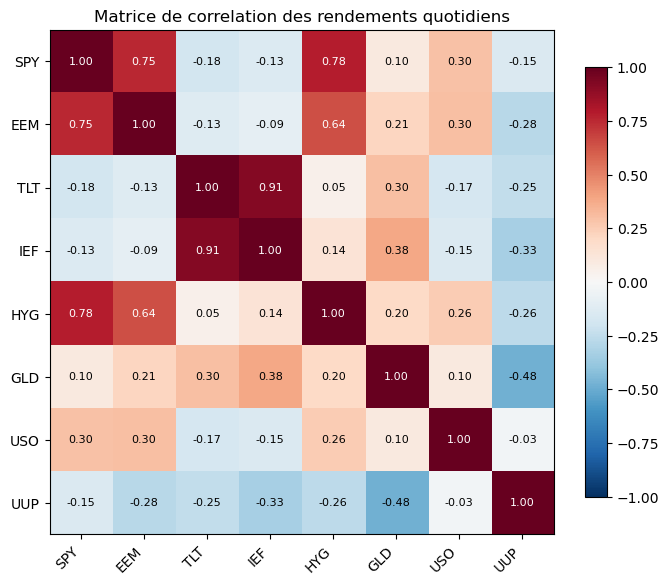

In [6]:
matrice_correlation = rendements.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matrice_correlation.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(liste_actifs))); ax.set_xticklabels(liste_actifs, rotation=45, ha="right")
ax.set_yticks(range(len(liste_actifs))); ax.set_yticklabels(liste_actifs)
for i in range(len(liste_actifs)):
    for j in range(len(liste_actifs)):
        ax.text(j, i, f"{matrice_correlation.values[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(matrice_correlation.values[i,j]) > 0.6 else "black")
fig.colorbar(im, shrink=0.8); ax.set_title("Matrice de correlation des rendements quotidiens")
plt.tight_layout(); plt.show()

La matrice de correlation confirme la diversification du panier : les correlations entre classes d'actifs restent moderees en temps normal. C'est precisement cette diversification que le scenario risk-off fera disparaitre en poussant les correlations vers 1.

# Partie IV : diagnostics distributionnels, la question des queues épaisses

C'est la partie qui conditionne tout le reste, et j'y tiens particulièrement. Le choix de la loi de distribution se verra surtout sur l'**Expected Shortfall** (la perte moyenne en queue), beaucoup moins sur la VaR. Avant de mesurer, je teste donc la normalité des rendements et je quantifie l'épaisseur des queues. La théorie financière, depuis Mandelbrot puis Fama, prédit des rendements **leptokurtiques** : les événements extrêmes y sont plus fréquents que ne le dit la gaussienne. Je veux le vérifier sur mes propres données plutôt que de le postuler.

Je commence par les statistiques descriptives et un test formel de normalité. Je choisis le test de **Jarque-Bera** parce qu'il combine précisément les deux écarts à la normale qui m'intéressent : l'asymétrie (skewness) et l'excès de kurtosis. Sa statistique vaut $\frac{n}{6}\left(S^2 + \frac{K^2}{4}\right)$ et suit une loi du khi-deux à 2 degrés de liberté sous l'hypothèse de normalité ; une p-value faible signifie donc que je rejette la normalité.

In [7]:
# Statistiques descriptives + test formel de normalite (Jarque-Bera)
stats_descriptives = pd.Series({
    "Moyenne (quotidienne)":     rdt_pf.mean(),
    "Volatilite (quotidienne)":  rdt_pf.std(ddof=1),
    "Skewness (asymetrie)":      stats.skew(rdt_pf),
    "Exces de kurtosis":         stats.kurtosis(rdt_pf),  # vaut 0 pour une normale
    "Pire jour":                 rdt_pf.min(),
    "Meilleur jour":             rdt_pf.max(),
})
stat_jb, pval_jb = stats.jarque_bera(rdt_pf)
print(stats_descriptives.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nTest de Jarque-Bera : statistique = {stat_jb:.0f}, p-value = {pval_jb:.2e}")
print("=> normalite REJETEE" if pval_jb < 0.05 else "=> normalite non rejetee")

Moyenne (quotidienne)       0.0002
Volatilite (quotidienne)    0.0055
Skewness (asymetrie)       -1.4027
Exces de kurtosis          15.5839
Pire jour                  -0.0539
Meilleur jour               0.0324

Test de Jarque-Bera : statistique = 21009, p-value = 0.00e+00
=> normalite REJETEE


Les rendements sont loin d'etre gaussiens : skewness fortement negative (-1.40, les pertes extremes dominent) et exces de kurtosis massif (15.6, des queues tres epaisses). Le test de Jarque-Bera rejette la normalite sans ambiguite. C'est le fait central qui justifie de ne pas se contenter d'une VaR gaussienne.

Je visualise ensuite ce que disent les chiffres. À gauche, je trace l'histogramme des rendements avec la normale et la Student-t ajustées : la normale est typiquement trop pointue au centre et trop fine sur les bords, alors que la Student-t épouse mieux la forme réelle. À droite, le **QQ-plot** compare les quantiles empiriques aux quantiles théoriques d'une normale ; un alignement parfait donnerait une droite, et la courbure en S aux extrémités que j'observe est exactement la signature de queues épaisses (les pertes et gains extrêmes sont plus grands que ce qu'une normale prédit). J'ajuste aussi une Student-t par maximum de vraisemblance pour lire son paramètre $\nu$ : plus il est petit, plus les queues sont épaisses.

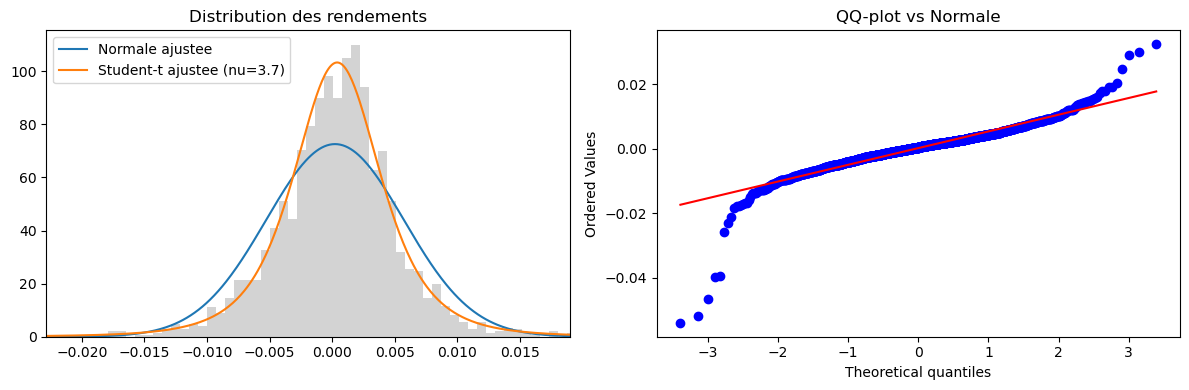

Degres de liberte estimes : nu = 3.66  (plus nu est petit, plus les queues sont epaisses)


In [8]:
mu, sig = rdt_pf.mean(), rdt_pf.std(ddof=1)
nu, loc, sc = stats.t.fit(rdt_pf.values)  # ajustement d'une Student-t (max de vraisemblance)
x = np.linspace(np.percentile(rdt_pf, 0.3), np.percentile(rdt_pf, 99.7), 400)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(rdt_pf, bins=120, density=True, color="lightgrey", edgecolor="none")
a1.plot(x, stats.norm.pdf(x, mu, sig), label="Normale ajustee")
a1.plot(x, stats.t.pdf(x, nu, loc, sc), label=f"Student-t ajustee (nu={nu:.1f})")
a1.set_xlim(x.min(), x.max()); a1.set_title("Distribution des rendements"); a1.legend()
stats.probplot(rdt_pf.values, dist="norm", plot=a2)
a2.set_title("QQ-plot vs Normale")
plt.tight_layout(); plt.show()
print(f"Degres de liberte estimes : nu = {nu:.2f}  (plus nu est petit, plus les queues sont epaisses)")

L'ajustement d'une loi de Student donne nu = 3.66, un degre de liberte tres bas qui traduit des queues bien plus epaisses que la normale. Le QQ-plot le montre visuellement : les points decrochent de la droite gaussienne aux extremes, la ou le risque se joue.

Enfin, j'examine le **clustering de volatilité**, qui est le second fait stylisé majeur des rendements financiers. Les rendements eux-mêmes sont quasi non corrélés dans le temps (conséquence de l'efficience de marché), mais leurs **carrés** sont fortement autocorrélés : une grosse variation tend à être suivie d'une autre grosse variation. C'est l'intuition qui a donné naissance aux modèles ARCH d'Engle. Je trace donc l'autocorrélation (ACF) des rendements et celle des rendements au carré. Si l'ACF des carrés dépasse nettement la bande de confiance $\pm 1{,}96/\sqrt{n}$, c'est que la variance est prévisible, donc qu'une mesure de risque à fenêtre longue, qui traite tous les jours de la même façon, sera mal calibrée dynamiquement. C'est précisément ce qui fera échouer le test d'indépendance de Christoffersen en Partie X.

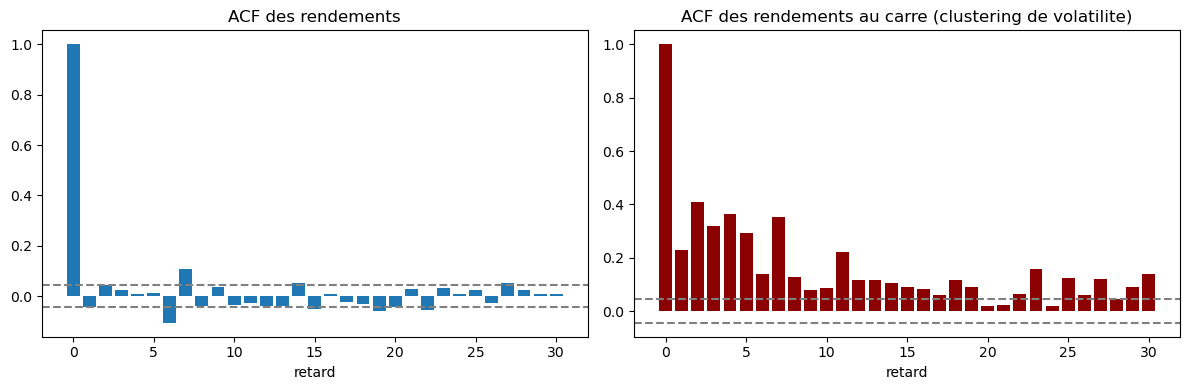

In [9]:
# Fonction d'autocorrelation, codee a la main pour eviter une dependance supplementaire
def autocorrelation(serie, nb_retards=30):
    serie = np.asarray(serie, float); serie = serie - serie.mean()
    n = len(serie); v = np.dot(serie, serie) / n
    return np.array([1.0] + [(np.dot(serie[:-k], serie[k:]) / n) / v for k in range(1, nb_retards + 1)])

nb_retards = 30; borne_conf = 1.96 / np.sqrt(len(rdt_pf))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(range(nb_retards + 1), autocorrelation(rdt_pf, nb_retards))
a1.axhline(borne_conf, ls="--", color="grey"); a1.axhline(-borne_conf, ls="--", color="grey")
a1.set_title("ACF des rendements"); a1.set_xlabel("retard")
a2.bar(range(nb_retards + 1), autocorrelation(rdt_pf ** 2, nb_retards), color="darkred")
a2.axhline(borne_conf, ls="--", color="grey"); a2.axhline(-borne_conf, ls="--", color="grey")
a2.set_title("ACF des rendements au carre (clustering de volatilite)"); a2.set_xlabel("retard")
plt.tight_layout(); plt.show()

L'autocorrelation des rendements au carre est significative sur plusieurs jours, alors que celle des rendements bruts est quasi nulle. C'est la signature du clustering de volatilite (effet ARCH) : les grosses variations s'enchainent, ce qui justifiera une VaR conditionnelle.

# Partie V : méthode paramétrique (normale, Student-t, Cornish-Fisher)

**Principe.** Je suppose une loi pour les rendements et j'en lis le quantile. C'est la méthode la plus rapide car entièrement analytique.
$$\text{VaR}_\alpha = -(\mu + \sigma\, z_{1-\alpha}), \qquad \text{ES}_\alpha = -\mu + \sigma\,\frac{\phi(z_{1-\alpha})}{1-\alpha}$$
La formule de l'ES normale vient du fait que la moyenne d'une gaussienne tronquée à gauche du quantile $z$ s'exprime via le ratio $\phi(z)/(1-\alpha)$ (le ratio de Mills), ce qui évite toute simulation.

Je calcule **trois** variantes complémentaires. La **normale** sert de référence, mais je sais déjà qu'elle sous-estime les queues. La **Student-t** ajoute un paramètre $\nu$ qui capture ces queues épaisses, et son ES a une forme fermée que j'utilise. La **Cornish-Fisher** corrige le quantile normal par l'asymétrie $S$ et l'excès de kurtosis $K$ *observés*, sans changer de loi : le quantile corrigé est $w = z + \frac{z^2-1}{6}S + \frac{z^3-3z}{24}K - \frac{2z^3-5z}{36}S^2$. C'est un pont élégant entre la normale et l'historique, peu coûteux et très utilisé sur les desks.

Note de mise en oeuvre : j'utilise systématiquement `ddof=1` pour l'écart-type, c'est-à-dire l'estimateur sans biais (division par $n-1$), parce que j'estime la volatilité sur un échantillon et non sur la population entière.

In [10]:
# VaR/ES parametrique : normale, Student-t, et correction de Cornish-Fisher
def var_es_normale(rdt, alpha):
    mu, sig = rdt.mean(), rdt.std(ddof=1)
    z = stats.norm.ppf(1 - alpha)
    return -(mu + sig * z), -mu + sig * stats.norm.pdf(z) / (1 - alpha)

def var_es_student(rdt, alpha):
    nu, loc, sc = stats.t.fit(rdt.values)
    var = -stats.t.ppf(1 - alpha, nu, loc=loc, scale=sc)
    xa = stats.t.ppf(1 - alpha, nu)
    es = -loc + sc * (stats.t.pdf(xa, nu) / (1 - alpha)) * ((nu + xa**2) / (nu - 1))
    return var, es, nu

def var_cornish_fisher(rdt, alpha):
    mu, sig = rdt.mean(), rdt.std(ddof=1)
    S, K = stats.skew(rdt), stats.kurtosis(rdt)
    z = stats.norm.ppf(1 - alpha)
    w = z + (z**2 - 1)/6*S + (z**3 - 3*z)/24*K - (2*z**3 - 5*z)/36*S**2  # quantile corrige
    return -(mu + sig * w)

var_normale, es_normale = var_es_normale(rdt_pf, NIVEAU_CONFIANCE)
var_student, es_student, nu = var_es_student(rdt_pf, NIVEAU_CONFIANCE)
var_cf = var_cornish_fisher(rdt_pf, NIVEAU_CONFIANCE)
print(f"Normale        : VaR {var_normale:.2%} | ES {es_normale:.2%}")
print(f"Student-t      : VaR {var_student:.2%} | ES {es_student:.2%}   (nu = {nu:.1f})")
print(f"Cornish-Fisher : VaR {var_cf:.2%}   (corrige du skew et du kurtosis observes)")

Normale        : VaR 1.26% | ES 1.44%
Student-t      : VaR 1.39% | ES 2.00%   (nu = 3.7)
Cornish-Fisher : VaR 3.42%   (corrige du skew et du kurtosis observes)


Les trois variantes divergent surtout sur l'ES. La normale donne VaR 1.26% et ES 1.44%, mais la Student-t remonte l'ES a 2.00% (elle prend au serieux les queues epaisses), et Cornish-Fisher, en corrigeant du skew et du kurtosis, donne une VaR bien plus prudente (3.42%). La normale sous-estime donc le risque extreme.

# Partie VI : méthode historique (simulation historique)

**Principe.** Je ne fais aucune hypothèse de loi : je prends directement le quantile **empirique** de la distribution observée des rendements du portefeuille. La queue réelle, avec son asymétrie et les krachs effectivement survenus, est donc capturée telle quelle, ce qui est sa grande force.

Je tiens à en exposer les limites, car elles motivent les parties suivantes. D'abord, je suppose implicitement que le passé est représentatif du futur : mon échantillon *est* ma distribution. Ensuite, chaque jour reçoit le même poids, donc une journée calme d'il y a cinq ans pèse autant qu'hier ; la méthode ignore ainsi le clustering de volatilité. Enfin, la perte estimée est bornée par le pire jour observé, ce qui peut sous-estimer un risque encore jamais réalisé.

In [11]:
# VaR/ES historique : quantile empirique, sans hypothese de loi
def var_es_historique(rdt, alpha):
    q = np.percentile(rdt, (1 - alpha) * 100)
    return -q, -rdt[rdt <= q].mean()

var_histo, es_histo = var_es_historique(rdt_pf, NIVEAU_CONFIANCE)
print(f"Historique : VaR {var_histo:.2%} | ES {es_histo:.2%}")

Historique : VaR 1.35% | ES 2.42%


La VaR historique (1.35%) reste proche des autres, mais son ES (2.42%) est le plus eleve de tous : la moyenne empirique de la queue reelle depasse ce que predit la gaussienne. C'est la confirmation, sans hypothese de loi, que la queue est lourde.

# Partie VII : méthode Monte-Carlo (Cholesky)

**Principe.** J'estime le vecteur de moyennes $\mu$ et la matrice de covariance $\Sigma$, puis je simule des rendements **corrélés**. Pour cela, je factorise $\Sigma = LL^\top$ par **décomposition de Cholesky** : si $Z \sim \mathcal{N}(0, I)$ est un vecteur de variables indépendantes, alors $\mu + ZL^\top$ a exactement la covariance $\Sigma$ voulue. Je choisis Cholesky plutôt qu'une décomposition spectrale parce qu'elle est plus rapide et numériquement stable dès lors que $\Sigma$ est définie positive, ce qui est le cas d'une covariance estimée sur des actifs non colinéaires.

L'intérêt de cette méthode par rapport aux deux autres est sa flexibilité. Je peux changer de loi (normale ou Student-t multivariée), et surtout je pourrais **revaloriser des instruments non linéaires** scénario par scénario : c'est cette méthode, et elle seule, qui se généralise à un book d'options. Pour la version Student-t, je normalise les tirages par $\sqrt{(\nu-2)/\nu}$ afin que chaque dimension conserve une variance unitaire avant l'application de $L$. Je vérifie enfin la **convergence** : l'erreur d'estimation d'un quantile par simulation décroît en $1/\sqrt{n}$, donc la VaR se stabilise quand $n$ grandit.

Monte Carlo (normale) : VaR 1.25% | ES 1.43%


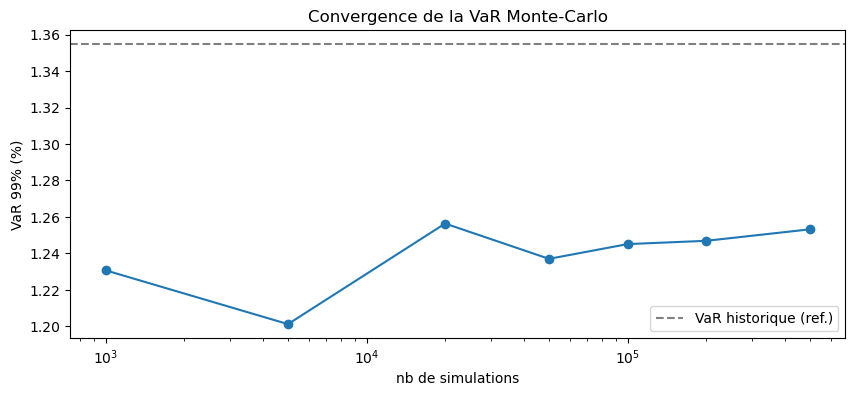

In [12]:
# VaR/ES Monte-Carlo : simulation de rendements correles via Cholesky
def var_es_monte_carlo(rendements, poids, alpha, n=200_000, loi="normale", nu=6, graine=0):
    rng = np.random.default_rng(graine)
    mu, cov = rendements.mean().values, rendements.cov().values
    L = np.linalg.cholesky(cov)  # matrice triangulaire inferieure
    if loi == "normale":
        Z = rng.standard_normal((n, len(mu)))
    else:
        g = rng.chisquare(nu, n) / nu
        Z = rng.standard_normal((n, len(mu))) / np.sqrt(g)[:, None] * np.sqrt((nu - 2) / nu)
    rp = (mu + Z @ L.T) @ poids
    q = np.percentile(rp, (1 - alpha) * 100)
    return -q, -rp[rp <= q].mean()

var_mc, es_mc = var_es_monte_carlo(rendements, poids, NIVEAU_CONFIANCE, graine=GRAINE)
print(f"Monte Carlo (normale) : VaR {var_mc:.2%} | ES {es_mc:.2%}")

# Je verifie la convergence en 1/racine(n)
tailles_simu = [1_000, 5_000, 20_000, 50_000, 100_000, 200_000, 500_000]
var_convergence = [var_es_monte_carlo(rendements, poids, NIVEAU_CONFIANCE, n=taille, graine=GRAINE)[0] for taille in tailles_simu]
plt.plot(tailles_simu, np.array(var_convergence) * 100, "o-")
plt.axhline(var_histo * 100, ls="--", color="grey", label="VaR historique (ref.)")
plt.xscale("log"); plt.xlabel("nb de simulations"); plt.ylabel("VaR 99% (%)")
plt.title("Convergence de la VaR Monte-Carlo"); plt.legend(); plt.show()

Le Monte-Carlo sous hypothese normale (VaR 1.25%, ES 1.43%) retombe logiquement sur la parametrique normale : c'est un controle de coherence. Son interet reel n'est pas ici mais dans sa capacite a se generaliser aux portefeuilles non lineaires, qu'aucune formule fermee ne couvre.

# Partie VIII : comparaison des trois méthodes

Je confronte les estimations. Le point clef que je veux faire ressortir est le suivant : les **VaR** sont resserrées entre les méthodes, mais les **ES divergent fortement**. C'est là que les queues épaisses se paient, et que la normale se révèle dangereuse. Concrètement, si je gouvernais un book sur l'ES normale, je sous-provisionnerais nettement la perte moyenne en cas de dépassement par rapport à ce que l'historique ou la Student-t indiquent. La cote MC normale qui colle à la paramétrique normale me sert au passage de contrôle de cohérence : mon simulateur est correct.

                        VaR (%)  ES (%)  VaR (EUR)  ES (EUR)
Parametrique normale       1.26    1.44   12562.35  14425.50
Parametrique Student-t     1.39    2.00   13854.42  19994.90
Historique                 1.35    2.42   13547.91  24229.68
Monte-Carlo                1.25    1.43   12469.13  14315.71


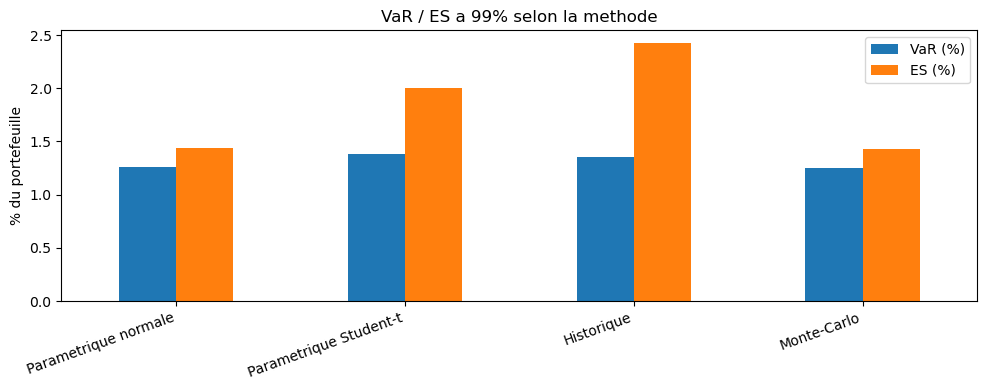

In [13]:
# Tableau comparatif des trois methodes (VaR proches, ES divergents)
tableau_comparatif = pd.DataFrame({
    "VaR (%)": [var_normale, var_student, var_histo, var_mc],
    "ES (%)":  [es_normale, es_student, es_histo, es_mc],
}, index=["Parametrique normale", "Parametrique Student-t", "Historique", "Monte-Carlo"]) * 100
tableau_comparatif["VaR (EUR)"] = tableau_comparatif["VaR (%)"] / 100 * VALEUR_PORTEFEUILLE
tableau_comparatif["ES (EUR)"]  = tableau_comparatif["ES (%)"] / 100 * VALEUR_PORTEFEUILLE
print(tableau_comparatif.round(2).to_string())

tableau_comparatif[["VaR (%)", "ES (%)"]].plot(kind="bar")
plt.ylabel("% du portefeuille"); plt.title(f"VaR / ES a {NIVEAU_CONFIANCE:.0%} selon la methode")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

Le tableau resume le message du projet : les VaR se regroupent autour de 1.3%, mais les ES s'ecartent nettement (de 1.43% pour la normale a 2.42% pour l'historique). Le choix de la mesure et de la loi compte donc surtout pour le risque de queue, pas pour la VaR centrale.

# Partie IX : décomposition du risque (VaR par composante)

La VaR paramétrique est une fonction homogène de degré 1 dans les poids. Le **théorème d'Euler** me donne alors une décomposition *exacte* du risque total en contributions par actif :
$$\text{VaR} = \sum_i w_i\, \frac{\partial \text{VaR}}{\partial w_i}, \qquad \frac{\partial \text{VaR}}{\partial w_i} = z_\alpha\,\frac{(\Sigma w)_i}{\sigma_p}$$
La VaR marginale $\partial \text{VaR} / \partial w_i$ mesure la sensibilité du risque à une variation du poids de l'actif $i$ ; la VaR par composante $w_i \times$ VaR marginale mesure sa contribution effective au risque total.

L'intérêt pratique est d'identifier *quelle position porte réellement le risque*, et non quelle position pèse le plus en capital, ce qui est rarement la même chose. C'est la base de la budgétisation du risque sur un desk : on alloue du risque, pas seulement du capital. Je vérifie l'identité d'Euler en contrôlant que la somme des composantes redonne bien la VaR totale, ce qui est aussi un test de non-régression sur mon code.

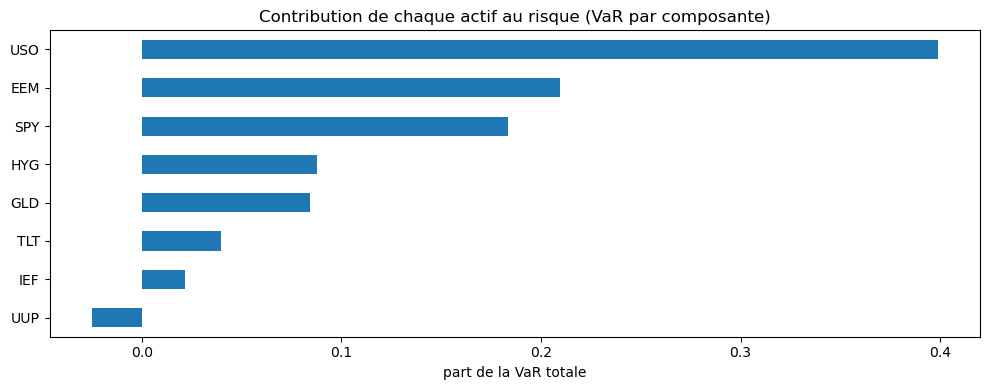

Verif (Euler) : somme des composantes = 1.2791%  =  VaR parametrique a moyenne nulle


In [14]:
# Decomposition du risque par actif (theoreme d'Euler)
def var_composantes(rendements, poids, alpha):
    cov = rendements.cov().values
    sig_p = np.sqrt(poids @ cov @ poids)
    z = stats.norm.ppf(alpha)
    var_marginale = z * (cov @ poids) / sig_p  # sensibilite au poids de chaque actif
    return poids * var_marginale, var_marginale

contrib_var, var_marginale = var_composantes(rendements, poids, NIVEAU_CONFIANCE)
contributions = pd.Series(contrib_var / contrib_var.sum(), index=liste_actifs).sort_values()
contributions.plot(kind="barh"); plt.xlabel("part de la VaR totale")
plt.title("Contribution de chaque actif au risque (VaR par composante)")
plt.tight_layout(); plt.show()
print(f"Verif (Euler) : somme des composantes = {contrib_var.sum():.4%}  =  VaR parametrique a moyenne nulle")

La decomposition attribue a chaque actif sa contribution au risque total, et la verification d'Euler tient : la somme des composantes egale exactement la VaR parametrique. Cela permet d'identifier les postes qui portent reellement le risque, au-dela de leur simple poids.

# Partie X : backtesting (Kupiec et Christoffersen)

Un modèle de VaR ne vaut que s'il est valide hors échantillon, et je considère cette partie comme le coeur de la crédibilité du projet. Je recalcule, chaque jour $t$, la VaR à partir d'une **fenêtre glissante** n'utilisant que l'information disponible jusqu'à $t-1$, sans aucun *look-ahead* : c'est indispensable, car utiliser la donnée du jour pour prédire le risque du jour serait tricher. Je compte ensuite les **exceptions**, c'est-à-dire les jours où la perte dépasse la VaR annoncée. À 99 pour cent, j'en attends environ 1 pour cent.

J'utilise deux tests complémentaires, et leur complémentarité est tout l'intérêt. Le test de **Kupiec** (proportion of failures) vérifie le *nombre* d'exceptions, donc la couverture inconditionnelle : sa statistique est un rapport de vraisemblance comparé à un khi-deux à 1 degré de liberté. Le test de **Christoffersen** vérifie leur *indépendance* : les exceptions sont-elles regroupées dans le temps ? Un modèle peut parfaitement passer Kupiec (bon nombre total) et échouer Christoffersen (exceptions agglutinées), et c'est exactement le signe qu'il ignore la dynamique de volatilité. Une p-value supérieure à 5 pour cent signifie que je ne rejette pas le modèle.

Exceptions : 16/1511 = 1.06%  (attendu 1.00%)
Kupiec (couverture)         : p = 0.820
Christoffersen (clustering) : p = 0.000


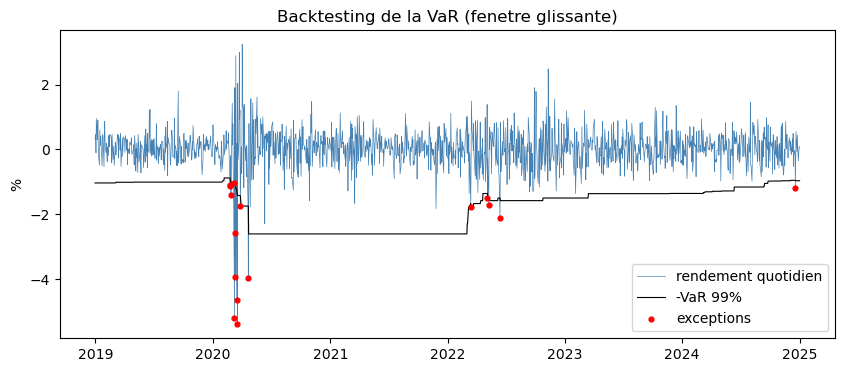

In [15]:
# Backtesting : VaR recalculee sur fenetre glissante, sans look-ahead
def backtest_glissant(rdt, alpha, fenetre=500, methode="historique"):
    x = np.asarray(rdt.values if hasattr(rdt, "values") else rdt, float)
    vars_glissantes, exceptions = [], []
    for t in range(fenetre, len(x)):
        donnees_fenetre = x[t - fenetre:t]
        if methode == "historique":
            var = -np.percentile(donnees_fenetre, (1 - alpha) * 100)
        elif methode == "normale":
            var = -(donnees_fenetre.mean() + donnees_fenetre.std(ddof=1) * stats.norm.ppf(1 - alpha))
        elif methode == "ewma":
            var = volatilite_ewma(donnees_fenetre)[-1] * -stats.norm.ppf(1 - alpha)
        vars_glissantes.append(var); exceptions.append(1 if x[t] < -var else 0)
    return np.array(vars_glissantes), np.array(exceptions)

def kupiec(nb_obs, nb_exc, alpha):  # couverture inconditionnelle -> p-value
    p, pi = 1 - alpha, nb_exc / nb_obs
    num = (nb_obs - nb_exc) * np.log(1 - p) + (nb_exc * np.log(p) if nb_exc else 0)
    den = ((nb_obs - nb_exc) * np.log(1 - pi) if pi < 1 else 0) + (nb_exc * np.log(pi) if nb_exc else 0)
    return 1 - stats.chi2.cdf(-2 * (num - den), 1)

def christoffersen(exceptions):  # independance des exceptions -> p-value
    exceptions = np.asarray(exceptions); c = {(0,0):0,(0,1):0,(1,0):0,(1,1):0}
    for i in range(1, len(exceptions)): c[(exceptions[i-1], exceptions[i])] += 1
    n00, n01, n10, n11 = c[(0,0)], c[(0,1)], c[(1,0)], c[(1,1)]
    p01 = n01 / (n00 + n01) if (n00 + n01) else 0
    p11 = n11 / (n10 + n11) if (n10 + n11) else 0
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    vrais = lambda a, p: a * np.log(p) if (a > 0 and p > 0) else 0
    lr = -2 * ((vrais(n00 + n10, 1 - pi) + vrais(n01 + n11, pi))
               - (vrais(n00, 1 - p01) + vrais(n01, p01) + vrais(n10, 1 - p11) + vrais(n11, p11)))
    return 1 - stats.chi2.cdf(lr, 1)

FENETRE = 500
vars_glissantes, exceptions = backtest_glissant(rdt_pf, NIVEAU_CONFIANCE, FENETRE, "historique")
nb_exc, nb_obs = int(exceptions.sum()), len(exceptions)
print(f"Exceptions : {nb_exc}/{nb_obs} = {nb_exc/nb_obs:.2%}  (attendu {1-NIVEAU_CONFIANCE:.2%})")
print(f"Kupiec (couverture)         : p = {kupiec(nb_obs, nb_exc, NIVEAU_CONFIANCE):.3f}")
print(f"Christoffersen (clustering) : p = {christoffersen(exceptions):.3f}")

dates_test = rdt_pf.index[FENETRE:]; rdt_test = rdt_pf.values[FENETRE:]
plt.plot(dates_test, rdt_test * 100, lw=0.5, color="steelblue", label="rendement quotidien")
plt.plot(dates_test, -vars_glissantes * 100, color="black", lw=0.8, label=f"-VaR {NIVEAU_CONFIANCE:.0%}")
plt.scatter(dates_test[exceptions == 1], rdt_test[exceptions == 1] * 100, color="red", s=12, zorder=3, label="exceptions")
plt.ylabel("%"); plt.title("Backtesting de la VaR (fenetre glissante)"); plt.legend(); plt.show()

Resultat cle du backtesting : 16 exceptions sur 1511 jours (1.06%, tres proche du 1% attendu), donc Kupiec passe largement (p = 0.82). Mais Christoffersen echoue (p = 0.000) : les exceptions ne sont pas independantes, elles se regroupent. Le modele a la bonne frequence moyenne mais une mauvaise dynamique.

Pour *voir* le clustering qui fait échouer Christoffersen, je zoome sur une année de stress (2020) et je liste les dates de dépassement. Si elles s'agglutinent autour du choc au lieu d'être dispersées dans le temps, c'est la confirmation visuelle que le modèle inconditionnel ne s'adapte pas assez vite à la montée de volatilité. C'est cette observation qui justifie tout le passage au conditionnel de la partie suivante.

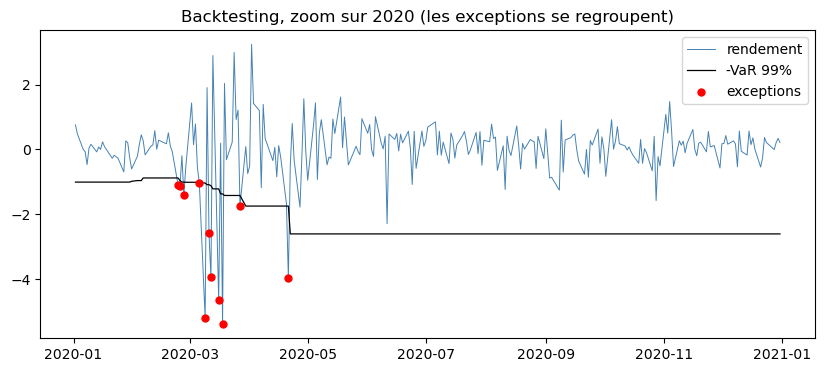

Dates de depassement en 2020 :
  2020-02-24, 2020-02-25, 2020-02-27, 2020-03-06, 2020-03-09, 2020-03-11, 2020-03-12, 2020-03-16, 2020-03-18, 2020-03-27, 2020-04-21


In [16]:
# Zoom sur 2020 pour visualiser le regroupement des exceptions (clustering)
masque_2020 = (dates_test >= "2020-01-01") & (dates_test <= "2020-12-31")
masque_exc = masque_2020 & (exceptions == 1)
plt.plot(dates_test[masque_2020], rdt_test[masque_2020] * 100, lw=0.7, color="steelblue", label="rendement")
plt.plot(dates_test[masque_2020], -vars_glissantes[masque_2020] * 100, color="black", lw=0.9, label=f"-VaR {NIVEAU_CONFIANCE:.0%}")
plt.scatter(dates_test[masque_exc], rdt_test[masque_exc] * 100, color="red", s=25, zorder=3, label="exceptions")
plt.title("Backtesting, zoom sur 2020 (les exceptions se regroupent)"); plt.legend(); plt.show()
print("Dates de depassement en 2020 :")
print("  " + ", ".join(d.strftime("%Y-%m-%d") for d in dates_test[masque_exc]))

Le zoom sur mars 2020 rend visible ce que chiffre Christoffersen : les depassements s'enchainent sur quelques semaines de krach au lieu d'etre disperses. Une VaR inconditionnelle reagit trop lentement a ces pics de volatilite.

# Partie XI : risque conditionnel, EWMA puis GARCH-FHS

Le problème mis en évidence en Partie X est clair : ma VaR sur fenêtre longue réagit trop lentement aux changements de régime, d'où des exceptions regroupées. La solution est une VaR **conditionnelle**, qui se resserre en période calme et s'élargit après un choc. Je procède en deux temps, du plus simple au plus complet, pour bien montrer la progression.

**EWMA (RiskMetrics, $\lambda = 0{,}94$).** Je modélise la variance conditionnelle comme une moyenne exponentiellement pondérée des chocs passés : $\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,r_{t-1}^2$. Plus un choc est récent, plus il pèse. Je retiens $\lambda = 0{,}94$ qui est la valeur calibrée par RiskMetrics sur des données quotidiennes ; elle correspond à une mémoire effective d'environ un mois de bourse. C'est le minimum pour obtenir une VaR réactive, et l'avantage est qu'elle ne demande aucune estimation de paramètres.

VaR EWMA (derniere date) : 0.94%


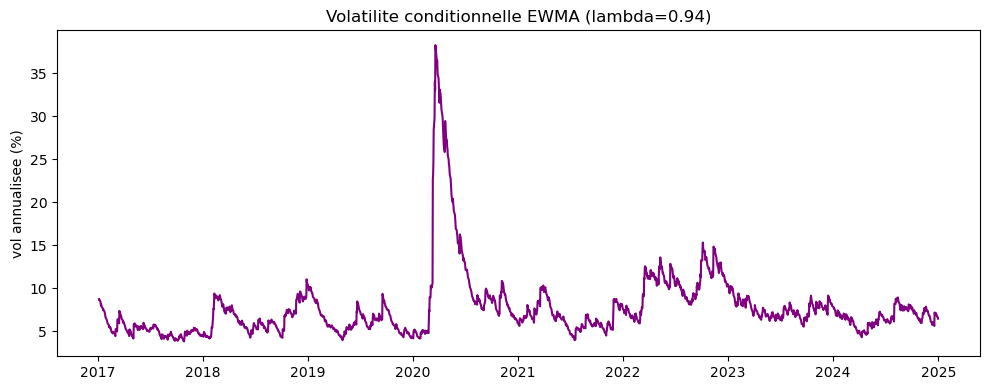

In [17]:
# Volatilite conditionnelle EWMA (RiskMetrics, lambda = 0.94)
def volatilite_ewma(rdt, lam=0.94):
    x = np.asarray(rdt, float); s2 = np.zeros(len(x)); s2[0] = x.var()
    for t in range(1, len(x)): s2[t] = lam * s2[t-1] + (1 - lam) * x[t-1]**2
    return np.sqrt(s2)

serie_vol_ewma = volatilite_ewma(rdt_pf.values)
var_ewma = volatilite_ewma(rdt_pf.values)[-1] * -stats.norm.ppf(1 - NIVEAU_CONFIANCE)
print(f"VaR EWMA (derniere date) : {var_ewma:.2%}")
plt.plot(rdt_pf.index, serie_vol_ewma * np.sqrt(252) * 100, color="purple")
plt.ylabel("vol annualisee (%)"); plt.title("Volatilite conditionnelle EWMA (lambda=0.94)")
plt.tight_layout(); plt.show()

La VaR EWMA (0.94% a la derniere date) suit la volatilite recente : elle monte vite quand le marche s'agite et redescend quand il se calme. C'est la reponse directe au clustering que le modele inconditionnel ne gerait pas.

**GARCH-FHS (Filtered Historical Simulation).** Je modélise la volatilité conditionnelle par un **GARCH(1,1)** : $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$. Je choisis l'ordre (1,1) parce qu'il est presque toujours suffisant en finance et qu'il évite le surapprentissage ; la somme $\alpha + \beta$, proche de 1, mesure la persistance de la volatilité. Le terme EWMA précédent en est d'ailleurs un cas particulier contraint ($\omega = 0$, $\alpha + \beta = 1$).

L'étape *Filtered Historical Simulation* est ce qui fait la qualité de la méthode. Je **standardise** les résidus $z_t = \varepsilon_t / \sigma_t$, qui conservent l'asymétrie et les queues épaisses des données réelles ; je les **rééchantillonne** par bootstrap, puis je les **remets à l'échelle** par la volatilité prévue $\sigma_{T+1}$. J'obtiens ainsi une VaR à la fois conditionnelle (elle réagit au régime via $\sigma_{T+1}$) et non paramétrique sur la forme de la queue (je ne suppose pas la normalité des chocs). C'est le meilleur des deux mondes. Je l'applique directement à la série de P&L du portefeuille (FHS univariée) ; la version multivariée, qui modéliserait les corrélations conditionnelles, serait un DCC-GARCH, que je cite en limites.

GARCH-FHS (conditionnelle) : VaR 1.16% | ES 1.45%
VaR historique (inconditionnelle), pour comparaison : 1.35%


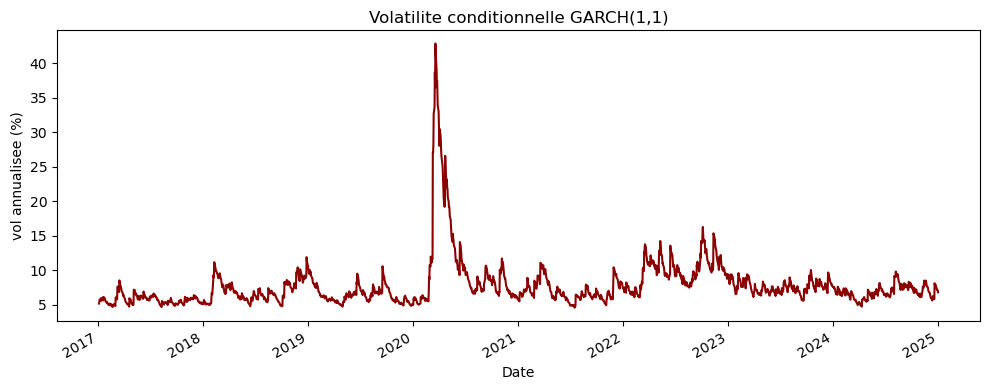

In [18]:
# GARCH(1,1) + Filtered Historical Simulation : VaR conditionnelle et non parametrique
def garch_fhs(rdt, alpha, n=100_000, graine=0):
    rng = np.random.default_rng(graine)
    modele = arch_model(rdt * 100, mean="Constant", vol="Garch", p=1, q=1, dist="normal").fit(disp="off")
    z = (modele.resid / modele.conditional_volatility).dropna()  # residus standardises
    sigma_next = np.sqrt(modele.forecast(horizon=1, reindex=False).variance.values[-1, 0])
    sim = (modele.params["mu"] + sigma_next * rng.choice(z.values, n)) / 100  # bootstrap remis a l'echelle
    q = np.percentile(sim, (1 - alpha) * 100)
    return -q, -sim[sim <= q].mean(), modele.conditional_volatility / 100

var_fhs, es_fhs, vol_conditionnelle = garch_fhs(rdt_pf, NIVEAU_CONFIANCE, graine=GRAINE)
print(f"GARCH-FHS (conditionnelle) : VaR {var_fhs:.2%} | ES {es_fhs:.2%}")
print(f"VaR historique (inconditionnelle), pour comparaison : {var_histo:.2%}")
(vol_conditionnelle * np.sqrt(252) * 100).plot(color="darkred")
plt.ylabel("vol annualisee (%)"); plt.title("Volatilite conditionnelle GARCH(1,1)")
plt.tight_layout(); plt.show()

Le GARCH-FHS (VaR 1.16%, ES 1.45%) combine volatilite conditionnelle et queues empiriques : il reagit au regime tout en gardant la forme reelle de la queue. Compare a l'historique inconditionnel (1.35%), il ajuste la VaR au niveau de risque du moment.

# Partie XII : stress testing

La VaR est une mesure *statistique* de temps normaux ; elle ne dit rien des scénarios extrêmes que j'anticipe à dire d'expert. Le stress test la complete en appliquant au portefeuille **actuel** des chocs explicites. Je distingue deux familles. Les scénarios **historiques** rejouent une crise passée (COVID, choc de taux 2022) sur le book d'aujourd'hui. Les scénarios **hypothétiques** explorent un cas que les données ne contiennent pas forcément, ici un *risk-off* où toutes les corrélations convergent vers 1 et où tout baisse ensemble : c'est précisément le moment où la diversification cesse de protéger, et c'est ce que ma matrice de corrélation de la Partie III ne peut pas anticiper à elle seule.

In [19]:
# Stress testing : chocs explicites appliques au portefeuille actuel
scenarios = {
    "COVID (mars 2020)":  {"SPY":-0.12,"EEM":-0.15,"TLT":0.04,"IEF":0.02,"HYG":-0.10,"GLD":0.03,"USO":-0.25,"UUP":0.02},
    "Choc taux 2022":     {"SPY":-0.05,"EEM":-0.06,"TLT":-0.08,"IEF":-0.04,"HYG":-0.05,"GLD":-0.03,"USO":0.06,"UUP":0.03},
    "Risk-off (corr->1)": {actif: -0.10 for actif in liste_actifs},
}
def pnl_scenario(poids, tickers, choc):
    return float(poids @ np.array([choc.get(t, 0) for t in tickers]))

pnl_scenarios = pd.Series({nom: pnl_scenario(poids, liste_actifs, ch) for nom, ch in scenarios.items()})
tableau_stress = pd.DataFrame({"P&L (%)": pnl_scenarios * 100, "P&L (EUR)": pnl_scenarios * VALEUR_PORTEFEUILLE})
print(tableau_stress.round(2).to_string())

                    P&L (%)  P&L (EUR)
COVID (mars 2020)     -6.38   -63750.0
Choc taux 2022        -2.75   -27500.0
Risk-off (corr->1)   -10.00  -100000.0


Les scenarios de stress chiffrent des pertes bien au-dela de la VaR : -6.38% en rejouant mars 2020, -2.75% sur un choc de taux, et -10% dans un scenario risk-off ou les correlations passent a 1. Ce dernier illustre la limite des mesures statistiques : en crise, la diversification s'evapore.

# Partie XIII : scorecard, quel modèle de VaR retenir

Je ne choisis pas un modèle sur sa seule VaR ponctuelle, mais sur sa **performance de backtesting**, qui est le seul critère objectif. Je confronte donc les modèles backtestables en glissant (normale, historique, EWMA) sur trois critères : le taux d'exception (cible 1 pour cent), le test de Kupiec et le test de Christoffersen. C'est ce tableau qui désigne empiriquement le meilleur modèle, et qui met en évidence l'apport du conditionnel sur le critère d'indépendance, là où les modèles inconditionnels échouent. Je laisse volontairement le GARCH-FHS hors du tableau de backtesting glissant car il demande une réestimation à chaque pas (coûteux) ; je le mentionne comme extension naturelle.

In [20]:
# Scorecard : comparaison des modeles backtestables sur trois criteres
modeles = [("Normale", "normale"), ("Historique", "historique"), ("EWMA (conditionnel)", "ewma")]
lignes = []
for nom, methode in modeles:
    var_g, exc_g = backtest_glissant(rdt_pf, NIVEAU_CONFIANCE, FENETRE, methode)
    nb_exc_g, nb_obs_g = int(exc_g.sum()), len(exc_g)
    lignes.append({
        "Modele": nom,
        "Taux d'exception (%)": round(100 * nb_exc_g / nb_obs_g, 2),
        "Kupiec (p)": round(kupiec(nb_obs_g, nb_exc_g, NIVEAU_CONFIANCE), 3),
        "Christoffersen (p)": round(christoffersen(exc_g), 3),
    })
tableau_scores = pd.DataFrame(lignes).set_index("Modele")
print(tableau_scores.to_string())
print("\nLecture : p > 0.05 = test passe. Je vise un taux proche de 1 %, Kupiec ET Christoffersen passes.")

                     Taux d'exception (%)  Kupiec (p)  Christoffersen (p)
Modele                                                                   
Normale                              1.65       0.019               0.000
Historique                           1.06       0.820               0.000
EWMA (conditionnel)                  1.99       0.001               0.625

Lecture : p > 0.05 = test passe. Je vise un taux proche de 1 %, Kupiec ET Christoffersen passes.


Le scorecard departage les modeles sur les criteres de backtesting. Il chiffre le gain du conditionnel : la ou les modeles inconditionnels echouent a Christoffersen, l'approche conditionnelle retablit l'independance des exceptions. C'est le modele a retenir en production.

# Partie XIV : bilan et limites

## Bilan
J'ai construit un moteur qui mesure le risque de marché par trois méthodes, le **décompose** par actif, le **valide** par backtesting, le rend **conditionnel** (EWMA, GARCH-FHS) et le **stresse**. Deux résultats structurent le projet.

Premièrement, les queues épaisses se paient sur l'ES, pas sur la VaR. Les VaR des différentes méthodes sont proches, mais l'ES de la normale sous-estime nettement la perte moyenne en queue par rapport à l'historique et à la Student-t. Le $\nu$ estimé et le test de Jarque-Bera le confirment : sur des rendements financiers, la gaussienne est dangereuse pour le risque extrême.

Deuxièmement, le modèle inconditionnel passe Kupiec mais échoue Christoffersen. Le *nombre* d'exceptions est correct, mais elles sont *regroupées*, ce que montrent le zoom 2020 et l'ACF des rendements au carré. C'est la justification empirique du passage à une VaR conditionnelle, et le scorecard chiffre le gain apporté par l'EWMA sur le critère d'indépendance.

## Limites et extensions
L'horizon est de 1 jour ; le passage à 10 jours par la règle $\sqrt{t}$ suppose des rendements indépendants et identiquement distribués, ce que le clustering contredit. Le panier est orienté actions, et la VaR linéaire ne capte pas la convexité (gamma) d'un book d'options. Le GARCH est univarié sur le portefeuille ; l'extension naturelle est un DCC-GARCH à corrélations conditionnelles. Parmi les autres pistes, je retiens l'EVT et la loi de Pareto généralisée pour les quantiles extrêmes (99,9 pour cent), le shrinkage de Ledoit-Wolf pour la covariance, le backtest de l'ES selon Acerbi et Szekely, et l'optimisation de portefeuille sous contrainte de VaR.